In [1]:
# Transformers example -> Reverseing sequence of numbers
print("Hey")

Hey


In [2]:
import haiku as hk
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import numpy as np
import optax

from probjax.nn.transformers import Transformer
from sbi.analysis import pairplot

In [ ]:
jax.devices()

[gpu(id=0),
 gpu(id=1),
 gpu(id=2),
 gpu(id=3),
 gpu(id=4),
 gpu(id=5),
 gpu(id=6),
 gpu(id=7)]

In [ ]:
# test

In [ ]:
def generate_data(key, n):
    key1, key2, key3, key4 = jrandom.split(key,4)
    theta0 = jrandom.uniform(key1, shape=(n,1))*4 - 2
    theta1 = jrandom.uniform(key2, shape=(n,1))*4 - 2
    r = jrandom.normal(key3, shape=(n,1)) * 0.01 + 0.1
    alpha = jrandom.uniform(key4, shape=(n,1)) * jnp.pi - 0.5 * jnp.pi
    sqrt2 = jnp.sqrt(2)

    x1 = (r * jnp.cos(alpha) + 0.25) + (-jnp.abs(theta0 + theta1) / sqrt2)
    x2 = (r * jnp.sin(alpha)) + ((theta1 - theta0) / sqrt2)

    return jnp.concatenate([theta0, theta1, x1, x2], axis=1).reshape(n, -1, 1)


data = generate_data(jrandom.PRNGKey(1), 10000)
mean = data.mean(axis=0)
std = data.std(axis=0)
T_max = data.shape[1]

node_ids = jnp.arange(T_max)
T_max

4

(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

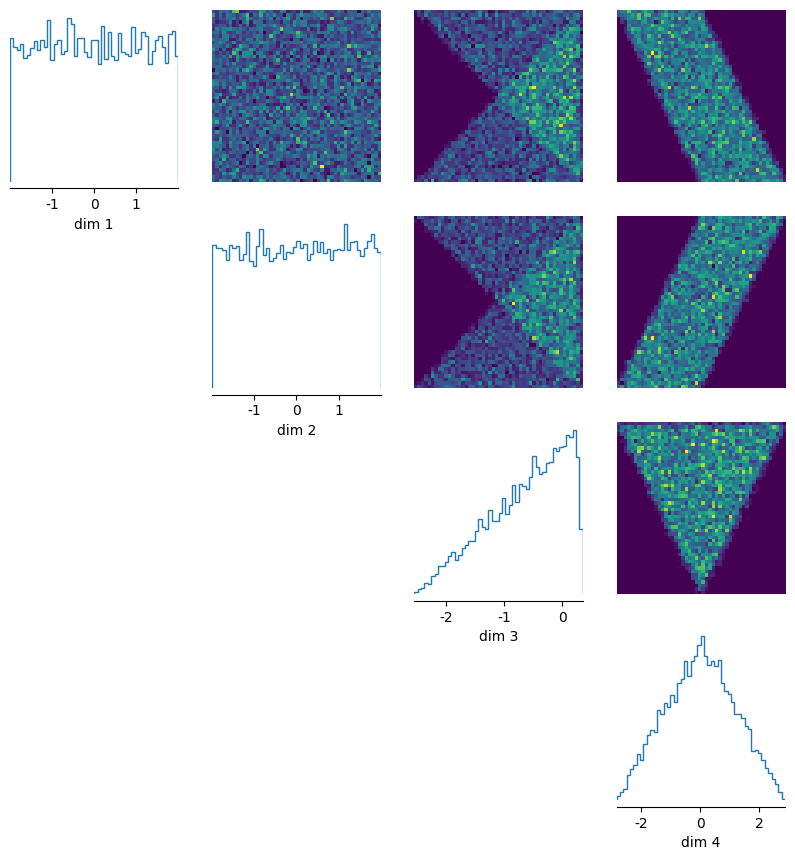

In [ ]:
pairplot(np.array(data[:, :, 0]))

In [21]:
key = jrandom.PRNGKey(0)

In [22]:
from probjax.nn.helpers import SinusoidalEmbedding

In [23]:

def model(t, x, node_ids, condition_mask):
    condition_mask = condition_mask.astype(int)
    # Embed values and conditions
    dim = 100
    _dim = dim // 2
    embedding_net = hk.nets.MLP([dim, _dim])
    embedding_id_nets = hk.Embed(T_max, _dim)
    embedding_time = hk.Sequential([SinusoidalEmbedding(_dim)])


    # Positional embedding

    model = Transformer(num_heads=4, num_layers=8, attn_size=10, dropout_rate=0.0, widening_factor=4)



    value_embeddings = embedding_net(x)
    id_embeddings = embedding_id_nets(node_ids)
    id_embeddings = jnp.broadcast_to(id_embeddings, value_embeddings.shape)

    time_embeddings = embedding_time(t.reshape(-1,1,1))

    condition_embedding = hk.get_parameter("condition_embedding", shape=(dim,), init=hk.initializers.RandomNormal(stddev=0.01))
    condition_embedding = condition_embedding.reshape(1,1, -1) * condition_mask.reshape(-1, x.shape[1],1)



    x_encoded = jnp.concatenate([value_embeddings, id_embeddings], axis=-1)
    x_encoded = x_encoded + condition_embedding

    # Encode
    h = model(x_encoded, context=time_embeddings)

    # Decode
    out = hk.Linear(1)(h)

    out = out * (1-condition_mask.reshape(-1,len(node_ids),1))
    return out


In [24]:
init, model_fn = hk.transform(model)
params = init(key, jnp.ones(data.shape[0]), data, node_ids, jnp.zeros_like(node_ids))

In [25]:
params = dict(jnp.load("transformer_based_inference_diffusion_two_moons.npz", allow_pickle=True))["params"]

In [26]:
params = dict(params.tolist())

In [27]:
jax.tree_util.tree_reduce(lambda x,y: x+y, jax.tree_map(lambda x: x.size, params))

823611

In [28]:
times = jax.random.uniform(key, (data.shape[0], 1, 1), minval=1e-6, maxval=1.0)
out = model_fn(params, key, times, data, node_ids, jnp.zeros_like(node_ids))

In [29]:
T = 1.
T_min = 1e-6
beta_min = 0.1
beta_max = 10.

def beta(t):
    return beta_min + t * (beta_max - beta_min)

def drift_fn(x, t):
    return -0.5 * (beta(t)) * x

def diffusion_fn(x, t):
    # This migh requrire a square root
    return jnp.sqrt(beta(t)) * jnp.ones_like(x)

def marginal_mean(x0, t):
    phi = jnp.exp(-0.25 * t**2 * (beta_max - beta_min) - 0.5*t * beta_min)
    return phi * x0

def marginal_std(x0, t):
    phi = jnp.exp(-0.5 * t**2 * (beta_max - beta_min) - t * beta_min)
    return jnp.sqrt(1 - 1 * phi)

def sbd_forward(key, x0, t):
    noise = jax.random.normal(key, x0.shape)
    std = marginal_std(x0, t)
    x_noised = marginal_mean(x0, t) + std * noise
    return x_noised

log_prob_fn = lambda x, t, x0: jax.scipy.stats.norm.logpdf(x, marginal_mean(x0, t), marginal_std(x0, t)).sum()
score_fn = jax.grad(log_prob_fn)

In [30]:
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)

valid_masks = jnp.stack([jnp.zeros(T_max, dtype=int), jnp.array([0,0, 1,1], dtype=int), jnp.array([1,1,0,0], dtype=int)])
def loss_fn(params, key, batch_size= 1024):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)

    # Generate data
    times = jax.random.uniform(rng_time, (batch_size, 1, 1), minval=T_min, maxval=1.0)
    batch_xs = generate_data(rng_data, batch_size) # n, T_max, 1



    # Condition mask -> randomly condition on some data -> Sample more frequently no condition
    valid_masks = jnp.stack([jnp.zeros(T_max, dtype=int), jnp.array([0,0, 1,1], dtype=int),jnp.array([0,0, 1,0], dtype=int),jnp.array([0,0, 0,1], dtype=int), jnp.array([0,1, 0,0], dtype=int),jnp.array([1,0, 0,0], dtype=int),jnp.array([1,1,0,0], dtype=int),jnp.array([1,0,1,0], dtype=int), jnp.array([0,1,0,1], dtype=int)])
    condition_mask = jax.random.choice(rng_condition, valid_masks, shape=(batch_size, ), axis=0)
    condition_mask = condition_mask[..., None]


    # Forward diffusion
    batch_noisy_xs = sbd_forward(rng_sample, batch_xs, times)
    batch_noisy_xs = batch_noisy_xs * (1-condition_mask) + batch_xs * condition_mask # Condition on the data

    score_pred = model_fn(params, rng_model, times, batch_noisy_xs, node_ids, condition_mask[...,0])
    score_target = score_fn(batch_noisy_xs, times, batch_xs)
    # Weighting function
    # Seems to be important here
    #lam = beta(times)
    lam = 1-jnp.exp(-0.5 * (beta_max - beta_min) * times**2 - beta_min * times) + 1e-4   # 1e-4 to avoid discarding samples
    # lam = 1.
    # Loss

    loss = jnp.mean(jnp.sum((1- condition_mask)*lam*(score_pred - score_target) ** 2, axis=-2))
    return loss


@jax.jit
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [31]:
from functools import partial


@partial(jax.pmap, axis_name="num_devices")
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)

    grads = jax.lax.pmean(grads, axis_name='num_devices')
    loss = jax.lax.pmean(loss, axis_name='num_devices')

    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [32]:
optimizer = optax.adam(5e-4)
opt_state = optimizer.init(params)

In [33]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [55]:
key = jrandom.PRNGKey(0)
for j in range(25):
    l = 0
    for i in range(1000):
        key, subkeys = jrandom.split(key)
        # loss, params, opt_state = update(params, key, opt_state)
        subkey = jrandom.split(subkeys, (n_devices,))
        loss, replicated_params, replicated_opt_state = update(replicated_params, subkey, replicated_opt_state)
        loss = loss[0]
        l += loss / 1000
    print(l)

0.77134097
0.4893024
0.45785382
0.44865674
0.4459393
0.43919694
0.44225487
0.43721226
0.43840817
0.43741843
0.43345982
0.43273425
0.43252528
0.43432233
0.43081787
0.43084067
0.43164685
0.4360529
0.42908645
0.42886743
0.42814392
0.4284283
0.42843685
0.42874253
0.42749223


In [56]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [57]:
jnp.savez("transformer_based_inference_diffusion_two_moons.npz", params=params)

In [34]:
from functools import partial

condition_mask = jnp.array([0]*T_max)
condition_value = jnp.array([0]*T_max)

def drift_backward(t, x, node_ids=node_ids, condition_mask=condition_mask):
    #t = T - t
    score = model_fn(params, key, t.reshape(-1, 1, 1), x.reshape(-1, len(node_ids), 1), node_ids,condition_mask[:len(node_ids)])
    score = score.reshape(x.shape)

    f =  drift_fn(x, t) - diffusion_fn(x, t)**2 * score
    f = f * (1-condition_mask)
    return f

def diffusion_backward(t,x, node_ids=node_ids,condition_mask=condition_mask):
    #t = T - t
    b =  diffusion_fn(x, t)
    b = b * (1-condition_mask[:len(node_ids)])
    return b

In [35]:
from probjax.utils.sdeint import sdeint

In [36]:


def sample_fn(key, shape, node_ids=node_ids, time_steps=200, condition_mask=jnp.zeros((T_max,), dtype=int), condition_value=jnp.zeros((T_max,))):
    condition_mask = condition_mask[:len(node_ids)]
    key1, key2 = jrandom.split(key, 2)
    x_T = jax.random.normal(key1, shape + (len(node_ids),)) * marginal_std(jnp.zeros(shape), 1.)
    x_T = x_T * (1-condition_mask) + condition_value * condition_mask
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, node_ids, condition_mask), lambda t, x: diffusion_backward(t, x, node_ids, condition_mask), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys

In [37]:
# def langevian_corrector(key, samples, T_min= T_min, h = 1e-3, node_ids=node_ids, condition_mask=jnp.zeros((T_max,), dtype=int), condition_value=jnp.zeros((T_max,))):

#     def langevian_step(carry, val):
#         key = val
#         x = carry[0]
#         score = model_fn(params, key, jnp.ones((1,1,1))*1e-3, x.reshape(-1, len(node_ids), 1), node_ids,condition_mask[:len(node_ids)])
#         score = score.reshape(x.shape)
#         x = x + score * h + jax.random.normal(key, x.shape) * jnp.sqrt(2*h)

#         return (x,), None

#     keys = jrandom.split(key, (samples.shape[0],))
#     init_carry = (samples,)
#     final_carray = jax.lax.scan(langevian_step, init_carry, keys)[0]
#     return final_carray[0]


In [38]:
samples = jax.pmap(lambda k: sample_fn(k, (4000, ), time_steps=800,node_ids=node_ids, condition_mask=condition_mask, condition_value=condition_value))(jrandom.split(jrandom.PRNGKey(0), n_devices))
samples = samples.reshape(4000*n_devices, -1, 4)

2023-11-02 16:35:16.611252: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:1541] Failed to get stream capture info: out of memory
2023-11-02 16:35:16.611325: W external/xla/xla/service/gpu/runtime/support.cc:58] Intercepted XLA runtime error:
INTERNAL: There was an error before calling cuModuleGetFunction (2): cudaErrorMemoryAllocation : out of memory
2023-11-02 16:35:16.611351: W external/xla/xla/stream_executor/stream.cc:277] Error blocking host until done in stream destructor: INTERNAL: stream did not block host until done; was already in an error state
2023-11-02 16:35:16.611425: E external/xla/xla/pjrt/pjrt_stream_executor_client.cc:2644] Execution of replica 1 failed: INTERNAL: Failed to instantiate GPU graphs: CaptureGpuGraph failed (There was an error before calling cuModuleGetFunction (2): cudaErrorMemoryAllocation : out of memory; current tracing scope: fusion.360): INTERNAL: failed to capture gpu graph: run time error: custom call 'xla.gpu.func.launch' failed
2023-11

XlaRuntimeError: INTERNAL: Failed to instantiate GPU graphs: CaptureGpuGraph failed (There was an error before calling cuModuleGetFunction (2): cudaErrorMemoryAllocation : out of memory; current tracing scope: fusion.360): INTERNAL: failed to capture gpu graph: run time error: custom call 'xla.gpu.func.launch' failed: while running replica 1 and partition 0 of a replicated computation (other replicas may have failed as well).

In [ ]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame(samples[:, -1, :])

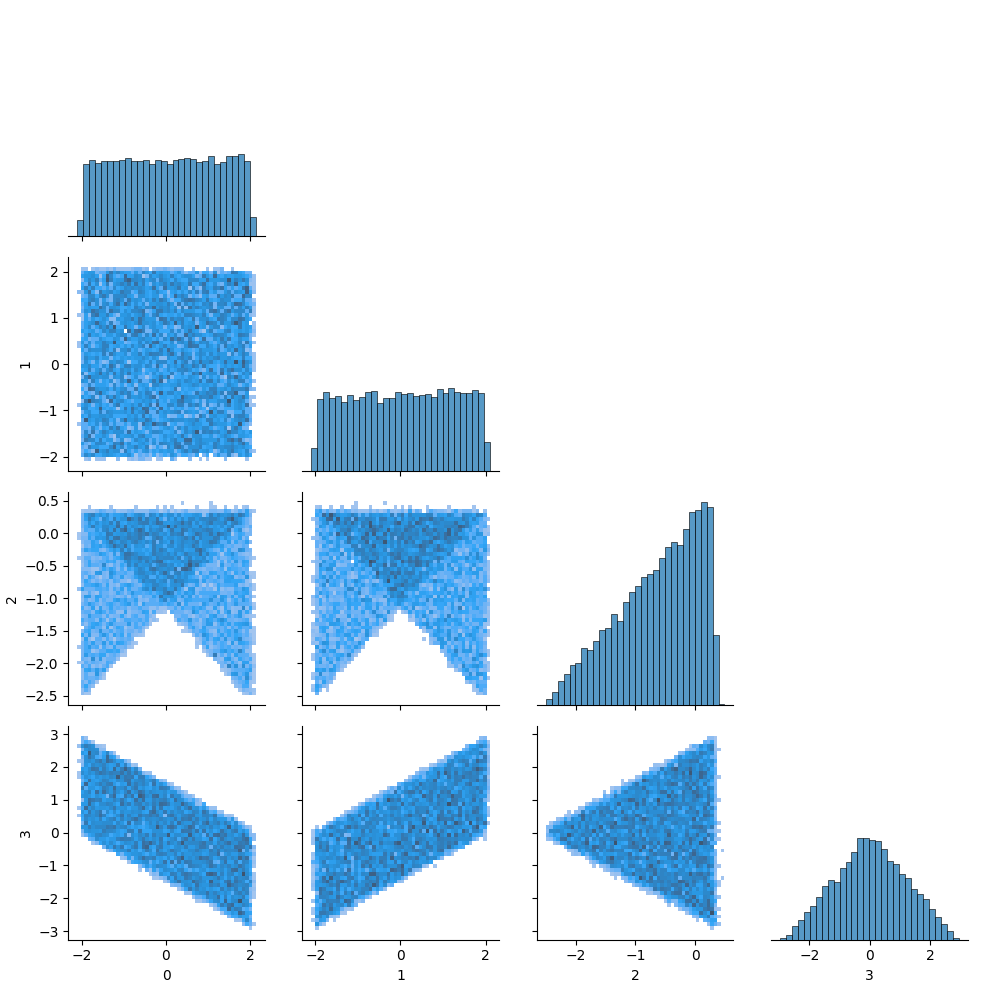

In [ ]:
%matplotlib widget

num_samples = 2000
condition_value = jnp.zeros((T_max,))
condition_mask = jnp.zeros((T_max,), dtype=int)
samples = jax.pmap(lambda k: sample_fn(k, (num_samples, ), time_steps=700,node_ids=node_ids, condition_mask=condition_mask, condition_value=condition_value))(jrandom.split(jrandom.PRNGKey(0), n_devices))
samples = samples.reshape(num_samples*n_devices, -1, 4)
df = pd.DataFrame(samples[:, -1, :])

g = sns.PairGrid(df, corner=True)
g.map_diag(sns.histplot, bins=30, stat="density")
g.map_lower(sns.histplot, bins=50)


def get_index(g, ax):
    for i in range(len(g.axes)):
        for j in range(len(g.axes)):
            if j > i:
                continue
            if str(ax) == str(g.axes[i,j]):
                return i,j

def get_ax_by_index(i, j):
    for ax in g.fig.axes:
        if str(ax) == str(g.axes[i,j]):
            return ax


points = [None] * len(g.axes)
drawings = [[None] * len(g.axes) for i in range(len(g.axes))]


def onclick(event):
    global condition_mask
    global condition_value
    global drawings

    ax = event.inaxes
    i,j = get_index(g, ax)

    for l in range(len(g.axes)):
        for m in range(len(g.axes)):
            if drawings[l][m] is not None:
                drawings[l][m].remove()
                drawings[l][m] = None


    if i == j:
        x_data, y_data =  ax.transData.inverted().transform((event.x, event.y))
        if points[i] is not None:
            points[i].remove()
            points[i] = None
            condition_value = condition_value.at[i].set(x_data)
            condition_mask = condition_mask.at[i].set(0)
        else:
            l =  ax.vlines(x_data, 0, 1., color="red")
            points[i] = l
            condition_value = condition_value.at[i].set(x_data)
            condition_mask = condition_mask.at[i].set(1)

        samples = jax.pmap(lambda k: sample_fn(k, (200, ), time_steps=200,node_ids=node_ids, condition_mask=condition_mask, condition_value=condition_value))(jrandom.split(jrandom.PRNGKey(0), n_devices))
        samples = samples.reshape(200*n_devices, -1, 4)
        df = pd.DataFrame(samples[:, -1, :])
        g.data = df

        def update_diag(x, **kwargs):
            ax = plt.gca()
            i,j = get_index(g, ax)
            if condition_mask[i] != 1:
                temp1 = ax.hist(x, **kwargs)[-1]
                drawings[i][i] = temp1
                return temp1
            else:
                return None

        def update_lower(x,y, **kwargs):
            ax = plt.gca()
            i,j = get_index(g, ax)

            if condition_mask[i] != 1 or condition_mask[j] != 1:
                temp1 = ax.scatter(x,y, **kwargs)
                drawings[i][j] = temp1
                return temp1
            else:
                val1, val2 = condition_value[i], condition_value[j]
                temp2 = ax.scatter(val1, val2, color="red")
                drawings[i][j] = temp2
                return temp2

        g.map_diag(update_diag, bins=30, color="C1", edgecolor='black', alpha=0.5, density=True)
        g.map_lower(update_lower, s=.1,alpha=0.5, color="C1")



    ax.figure.canvas.draw()



g.fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()

In [138]:
axes_f[1].remove()

(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

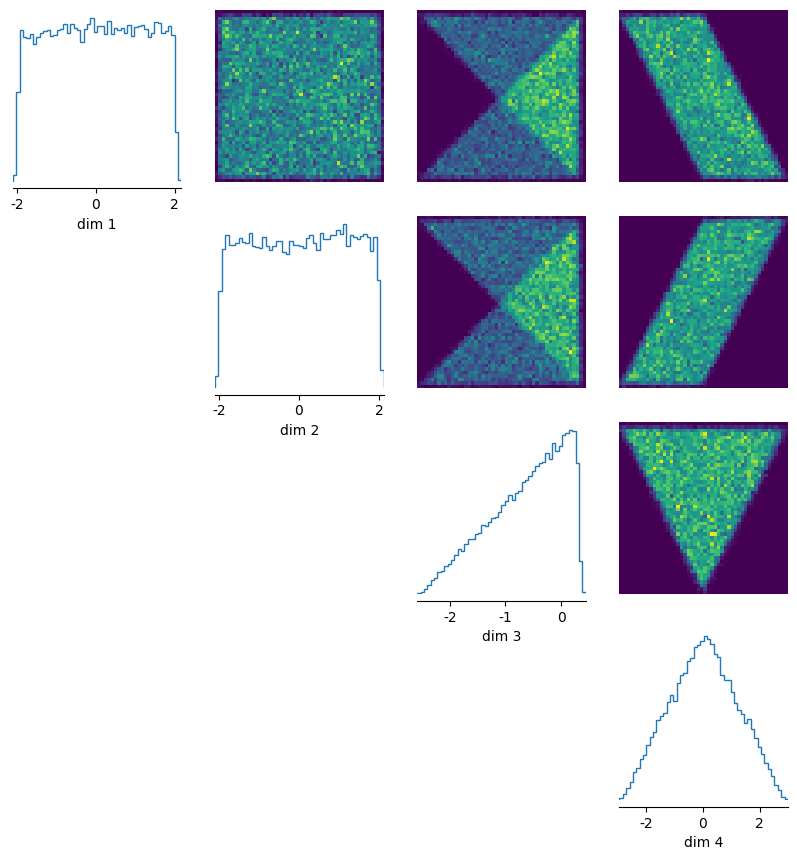

In [69]:
pairplot(np.array(samples[...,-1, :]))

(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

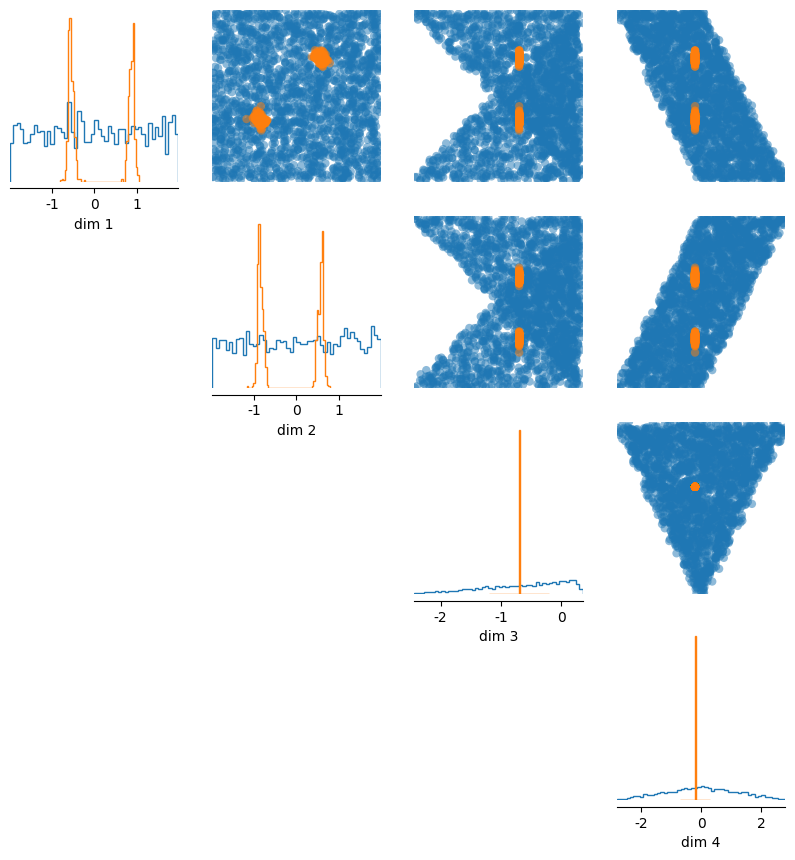

In [26]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([0,0,1,1]), condition_value=jnp.array([0., 0., -0.7, -0.2]), time_steps=400)
pairplot([np.array(data[:2000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

In [27]:
samples = jax.pmap(lambda k: sample_fn(k, (2000, ), time_steps=3000,node_ids=node_ids, condition_mask=jnp.array([0,0,1,1]), condition_value=jnp.array([0., 0., -0., -0.])))(jrandom.split(jrandom.PRNGKey(0), n_devices))
samples = samples.reshape(2000*n_devices, -1, 4)

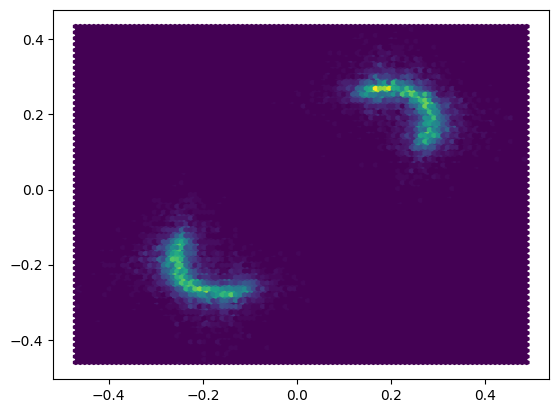

In [28]:
plt.hexbin(samples[...,-1, 0], samples[...,-1, 1], gridsize=100)

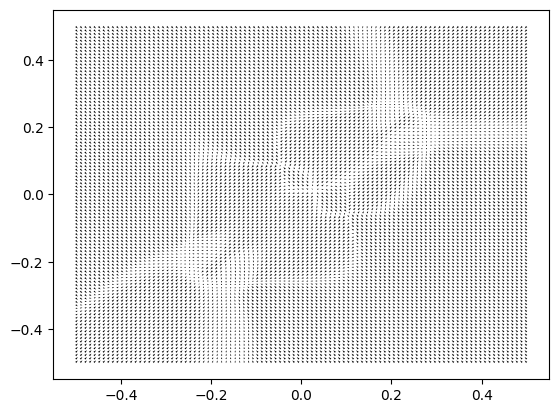

In [29]:
x = np.linspace(-0.5,0.5,100)
y = np.linspace(-0.5,0.5,100)
pos = np.dstack(np.meshgrid(x, y))
input_1 = pos.reshape(-1, 2, 1)
input2 =  jnp.zeros(input_1.shape)
input = jnp.concatenate([input_1, input2], axis=-2)
v = model_fn(params, key, jnp.ones((1,1,1))*1e-3, input, node_ids, condition_mask=jnp.array([0,0,1,1]))
v = v[:, :2,:]
v = v.reshape(100,100,2)
_ = plt.quiver(x, y, v[...,0], v[...,1])


(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

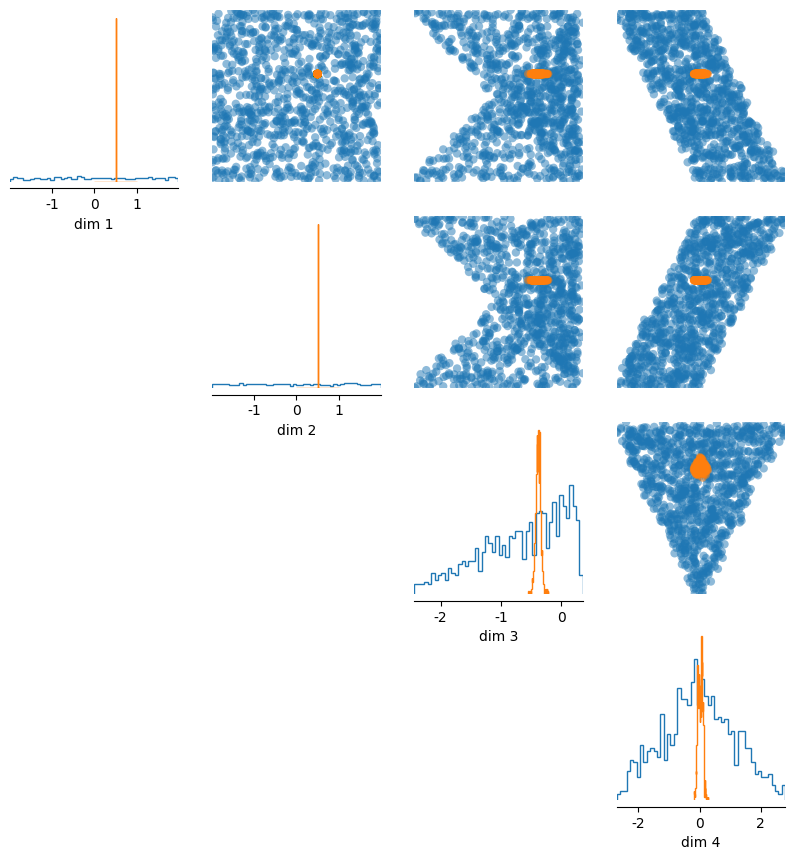

In [30]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([1,1,0,0]), condition_value=jnp.array([0.5,0.5,0,0]), time_steps=400)
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

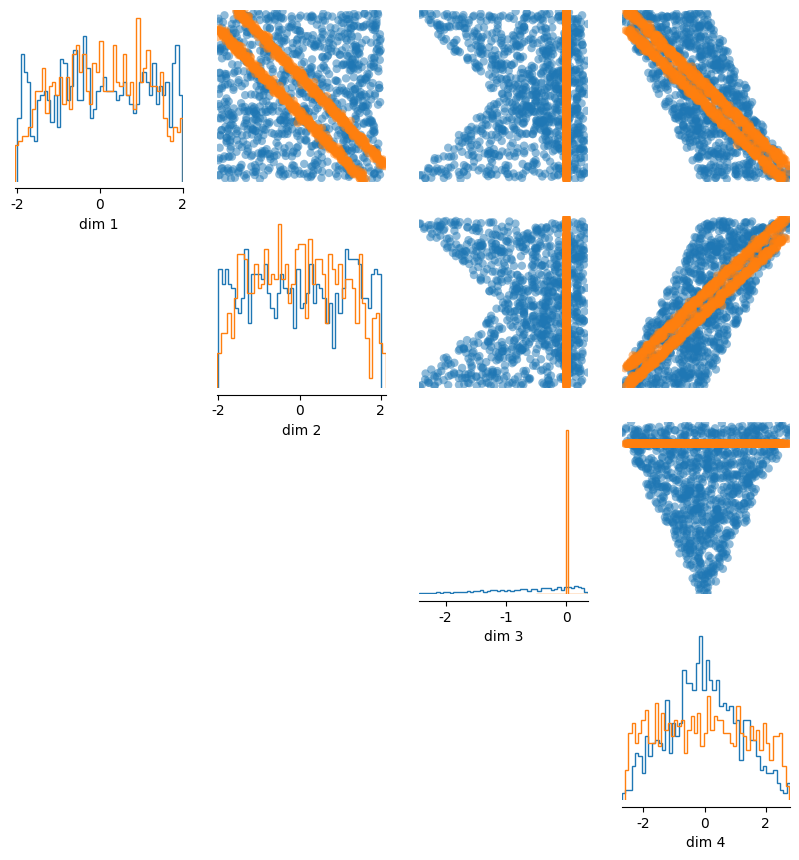

In [31]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([0,0,1,0]), condition_value=jnp.array([0.5,0.5,0,0]), time_steps=400)
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")